In [1]:
# importing the libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [2]:
# getting the dataset

import kagglehub

# Download latest version
path = kagglehub.dataset_download("yasserh/titanic-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'titanic-dataset' dataset.
Path to dataset files: /kaggle/input/titanic-dataset


In [3]:
# Phase 2: Data Exploration & Analysis
# loading the dataset
df = pd.read_csv(path + '/Titanic-Dataset.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
df.isna().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [6]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
# chaning the survival rate from 0, 1 to yes, no
df['Survived'] = df['Survived'].map({0: 'No', 1: 'Yes'})

# changing the port name to it's full name
df['Embarked'] = df['Embarked'].map({'S': 'Southampton', 'C': 'Cherbourg', 'Q': 'Queenstown'})

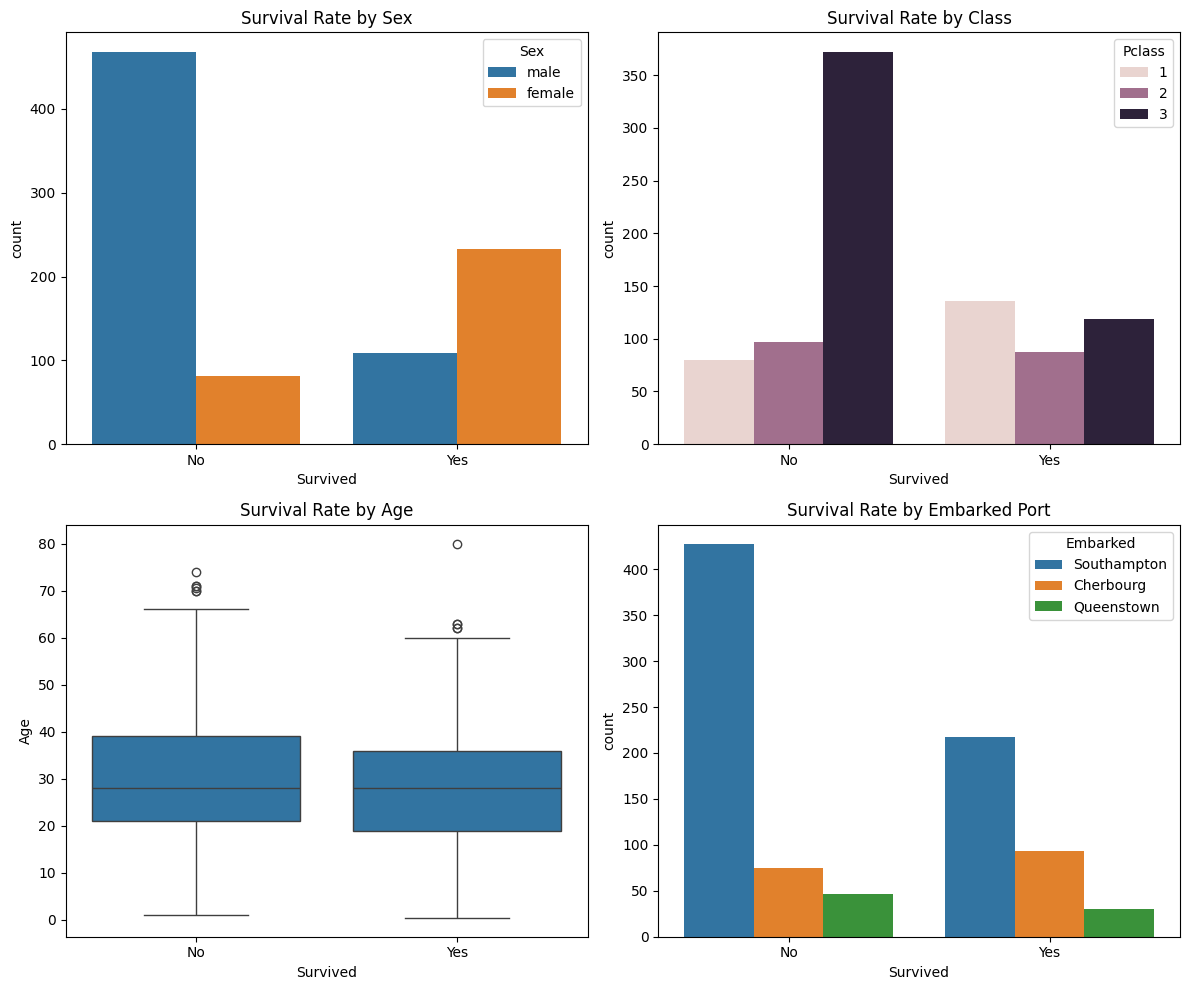

In [8]:
# visualizing survival rate by (gender, class, age group, and embarkation point)
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))
axes = axes.flatten()

# Plot survival rate vs Sex
sns.countplot(x='Survived', hue='Sex', data=df, ax=axes[0])
axes[0].set_title('Survival Rate by Sex')

# Plot survival rate vs Pclass
sns.countplot(x='Survived', hue='Pclass', data=df, ax=axes[1])
axes[1].set_title('Survival Rate by Class')

# Plot survival rate vs Age Group
sns.boxplot(x='Survived', y='Age', data=df, ax=axes[2])
axes[2].set_title('Survival Rate by Age')

# Plot survival rate vs Embarked
sns.countplot(x='Survived', hue='Embarked', data=df, ax=axes[3])
axes[3].set_title('Survival Rate by Embarked Port')

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

# saving those plots for presentation
fig.savefig('survival_rate_plots.png', dpi=300, bbox_inches='tight')

In [9]:
# Phase 3: Data Cleaning

# filling in the empty embarked point with the mode
df.fillna({'Embarked': df['Embarked'].mode()[0]}, inplace=True)

# filling in the missing ages with the mean
df.fillna({'Age': df['Age'].median()}, inplace=True)
df['Age'].value_counts()

# creating groups of ages
bins = [0, 18, 45, np.inf]
labels = ['children', 'adults', 'seniors']

df['Age Group'] = pd.cut(df['Age'], bins=bins, labels=labels)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   PassengerId  891 non-null    int64   
 1   Survived     891 non-null    object  
 2   Pclass       891 non-null    int64   
 3   Name         891 non-null    object  
 4   Sex          891 non-null    object  
 5   Age          891 non-null    float64 
 6   SibSp        891 non-null    int64   
 7   Parch        891 non-null    int64   
 8   Ticket       891 non-null    object  
 9   Fare         891 non-null    float64 
 10  Cabin        204 non-null    object  
 11  Embarked     891 non-null    object  
 12  Age Group    891 non-null    category
dtypes: category(1), float64(2), int64(4), object(6)
memory usage: 84.7+ KB


In [10]:
# finding if cabin is a important feature for survival or not

In [11]:
# Phase 4: Feature Engineering

# getting the family size
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
# checking if the person is alone or with family
df['IsAlone'] = 0
df.loc[df['FamilySize'] == 1, 'IsAlone'] = 1
# extracting the titles like mr. mrs. and more
df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
# combining the titles which don't occurs a lot into a rare title
df['Title'] = df['Title'].replace(['Lady', 'Countess','Capt', 'Col','Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
# replacing the french titles into english version
df['Title'] = df['Title'].replace('Mlle', 'Miss')
df['Title'] = df['Title'].replace('Ms', 'Miss')
df['Title'] = df['Title'].replace('Mme', 'Mrs')
# calculating fare per person
df['FarePerPerson'] = df['Fare'] / df['FamilySize']

# seprating x and y
features = ['Pclass', 'Sex', 'Age Group', 'SibSp', 'Parch', 'Fare', 'Embarked', 'Title', 'FamilySize', 'IsAlone']
X = df[features]
y = df['Survived']

print("Current feature list:")
print(X.columns.tolist())
X.head()

Current feature list:
['Pclass', 'Sex', 'Age Group', 'SibSp', 'Parch', 'Fare', 'Embarked', 'Title', 'FamilySize', 'IsAlone']


,Pclass,Sex,Age Group,SibSp,Parch,Fare,Embarked,Title,FamilySize,IsAlone
0,3,male,adults,1,0,7.2500,Southampton,Mr,2,0
1,1,female,adults,1,0,71.2833,Cherbourg,Mrs,2,0
2,3,female,adults,0,0,7.9250,Southampton,Miss,1,1
3,1,female,adults,1,0,53.1000,Southampton,Mrs,2,0
4,3,male,adults,0,0,8.0500,Southampton,Mr,1,1


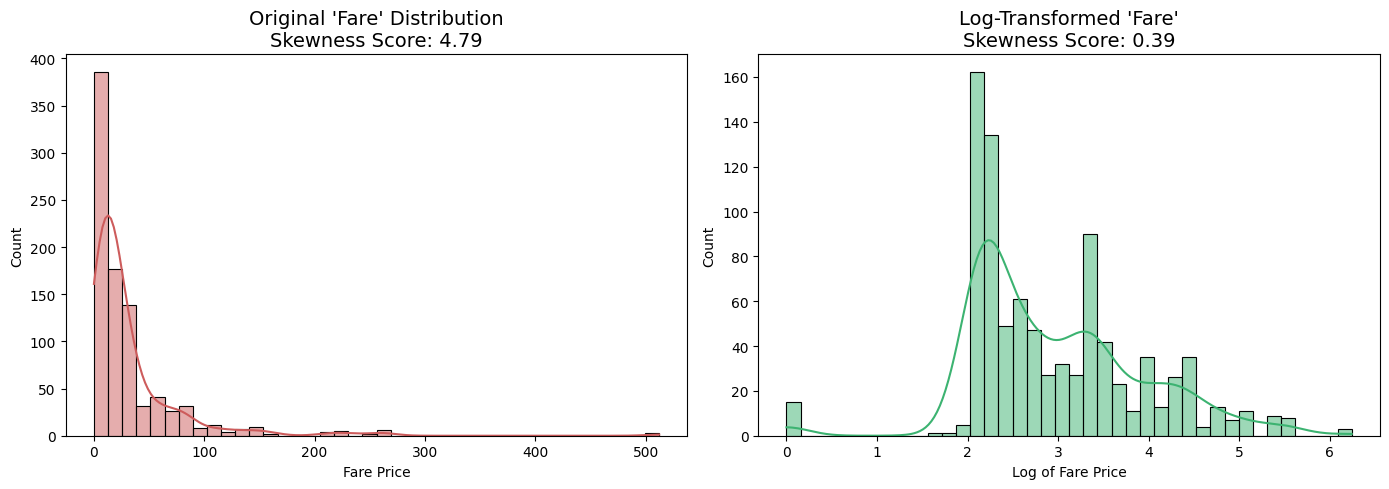

In [12]:
# checking for skewness before and after normalization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# original fare graph
sns.histplot(df['Fare'], bins=40, kde=True, color='indianred', ax=axes[0])

# checking for skewness>1 means it's highly skewed
original_skew = df['Fare'].skew()
axes[0].set_title(f"Original 'Fare' Distribution\nSkewness Score: {original_skew:.2f}", fontsize=14)
axes[0].set_xlabel("Fare Price")

# after log transformation the fare
log_fare = np.log1p(df['Fare'])
sns.histplot(log_fare, bins=40, kde=True, color='mediumseagreen', ax=axes[1])

# Calculating new skewness
new_skew = log_fare.skew()
axes[1].set_title(f"Log-Transformed 'Fare'\nSkewness Score: {new_skew:.2f}", fontsize=14)
axes[1].set_xlabel("Log of Fare Price")

plt.tight_layout()
plt.show()

In [13]:
# normalizing the fare to fixing the skewness
df['Fare'] = np.log1p(df['Fare'])

In [14]:
X.columns.to_list()

['Pclass',
 'Sex',
 'Age Group',
 'SibSp',
 'Parch',
 'Fare',
 'Embarked',
 'Title',
 'FamilySize',
 'IsAlone']

--- Training Models with Pipeline + GridSearchCV ---

--- Logistic Regression ---
Best Parameters: {'classifier__C': 10, 'classifier__solver': 'lbfgs'}
Accuracy: 0.8515
              precision    recall  f1-score   support

          No       0.86      0.91      0.88       220
         Yes       0.84      0.75      0.80       137

    accuracy                           0.85       357
   macro avg       0.85      0.83      0.84       357
weighted avg       0.85      0.85      0.85       357



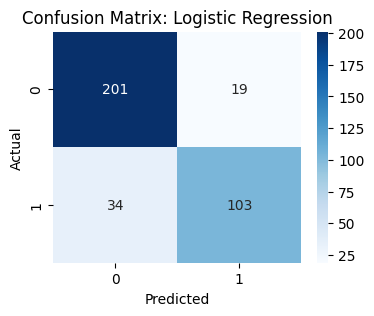


--- Decision Tree ---
Best Parameters: {'classifier__max_depth': 5, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2}
Accuracy: 0.8375
              precision    recall  f1-score   support

          No       0.86      0.89      0.87       220
         Yes       0.81      0.76      0.78       137

    accuracy                           0.84       357
   macro avg       0.83      0.82      0.83       357
weighted avg       0.84      0.84      0.84       357



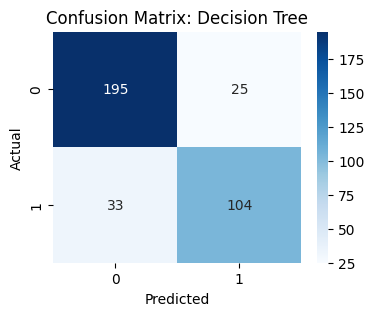


--- Random Forest ---
Best Parameters: {'classifier__max_depth': None, 'classifier__min_samples_split': 10, 'classifier__n_estimators': 100}
Accuracy: 0.8375
              precision    recall  f1-score   support

          No       0.83      0.93      0.88       220
         Yes       0.86      0.69      0.76       137

    accuracy                           0.84       357
   macro avg       0.84      0.81      0.82       357
weighted avg       0.84      0.84      0.83       357



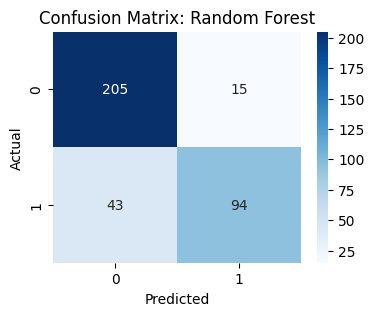


--- Pipeline Model Comparison Summary ---
Logistic Regression: 0.8515
Decision Tree: 0.8375
Random Forest: 0.8375


In [15]:
# categorizing cols for hot encoding inside pipeline
numeric_cols = ['Pclass', 'Fare', 'FamilySize', 'SibSp', 'Parch']
categorical_cols = ['Sex', 'Embarked', 'Title', 'Age Group']

# splitting the dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, random_state=42, stratify=y)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
    ],
    remainder='drop'
)

# Initialize models and their hyperparameter grids
models_and_params = {
    "Logistic Regression": {
        "model": LogisticRegression(max_iter=1000, random_state=42),
        "params": {
            'classifier__C': [0.01, 0.1, 1, 10],
            'classifier__solver': ['liblinear', 'lbfgs']
        }
    },
    "Decision Tree": {
        "model": DecisionTreeClassifier(random_state=42),
        "params": {
            'classifier__max_depth': [None, 5, 10, 15],
            'classifier__min_samples_split': [2, 5, 10],
            'classifier__min_samples_leaf': [1, 2, 4]
        }
    },
    "Random Forest": {
        "model": RandomForestClassifier(random_state=42),
        "params": {
            'classifier__n_estimators': [50, 100, 200],
            'classifier__max_depth': [None, 5, 10],
            'classifier__min_samples_split': [2, 5, 10]
        }
    }
}

results = {}
best_models = {}

print("--- Training Models with Pipeline + GridSearchCV ---")

for name, model_info in models_and_params.items():

    # Snap the preprocessor and the model together into a Pipeline
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model_info["model"])
    ])

    grid = GridSearchCV(pipeline, model_info["params"], cv=5, scoring='accuracy', n_jobs=-1)

    # Fitting the grid search on training data
    grid.fit(X_train, y_train)

    # Finding the best estimator
    best_pipeline = grid.best_estimator_
    best_models[name] = best_pipeline

    print(f"\n--- {name} ---")
    print(f"Best Parameters: {grid.best_params_}")

    # Predict on test data using the best pipeline
    y_pred = best_pipeline.predict(X_test)

    # Store and print results
    accuracy = accuracy_score(y_test, y_pred)
    results[name] = accuracy

    print(f"Accuracy: {accuracy:.4f}")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix Visualization
    plt.figure(figsize=(4,3))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix: {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

print("\n--- Pipeline Model Comparison Summary ---")
for name, score in results.items():
    print(f"{name}: {score:.4f}")

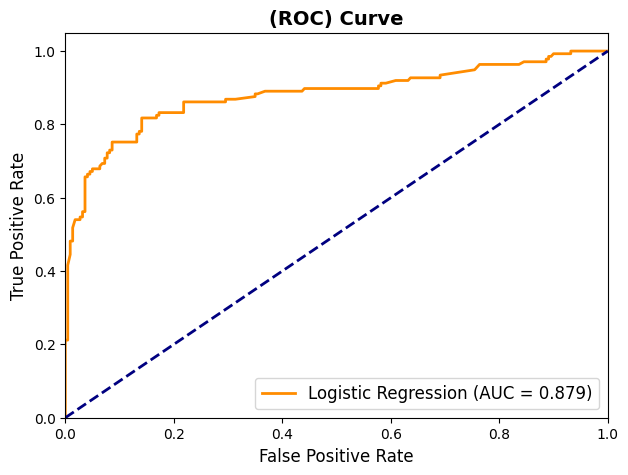

In [16]:
# Bonus: ROC Curve for the Best Model
y_pred_prob = best_models["Logistic Regression"].predict_proba(X_test)[:, 1]

# Converting y_test to numerical labels for roc_curve and roc_auc_score
y_test_numeric = y_test.map({'No': 0, 'Yes': 1})

# Calculating the False Positive Rate and True Positive Rate
fpr, tpr, thresholds = roc_curve(y_test_numeric, y_pred_prob)

# Calculating the AUC Score
auc_score = roc_auc_score(y_test_numeric, y_pred_prob)

# plotting the ROC Curve
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Logistic Regression (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('(ROC) Curve', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=12)
plt.show()

In [17]:
# Phase 6: Final Prediction
final_model = best_models["Logistic Regression"]
final_predictions = final_model.predict(X_test)

passenger_ids = df.loc[X_test.index, 'PassengerId']
submission = pd.DataFrame({
    'PassengerId': passenger_ids,
    'Survived': final_predictions
})

submission.to_csv('titanic_submission.csv', index=False)
print("Successfully created 'titanic_submission.csv'!")
display(submission.head())

Successfully created 'titanic_submission.csv'!


,PassengerId,Survived
369,370,Yes
541,542,No
196,197,No
810,811,No
427,428,Yes


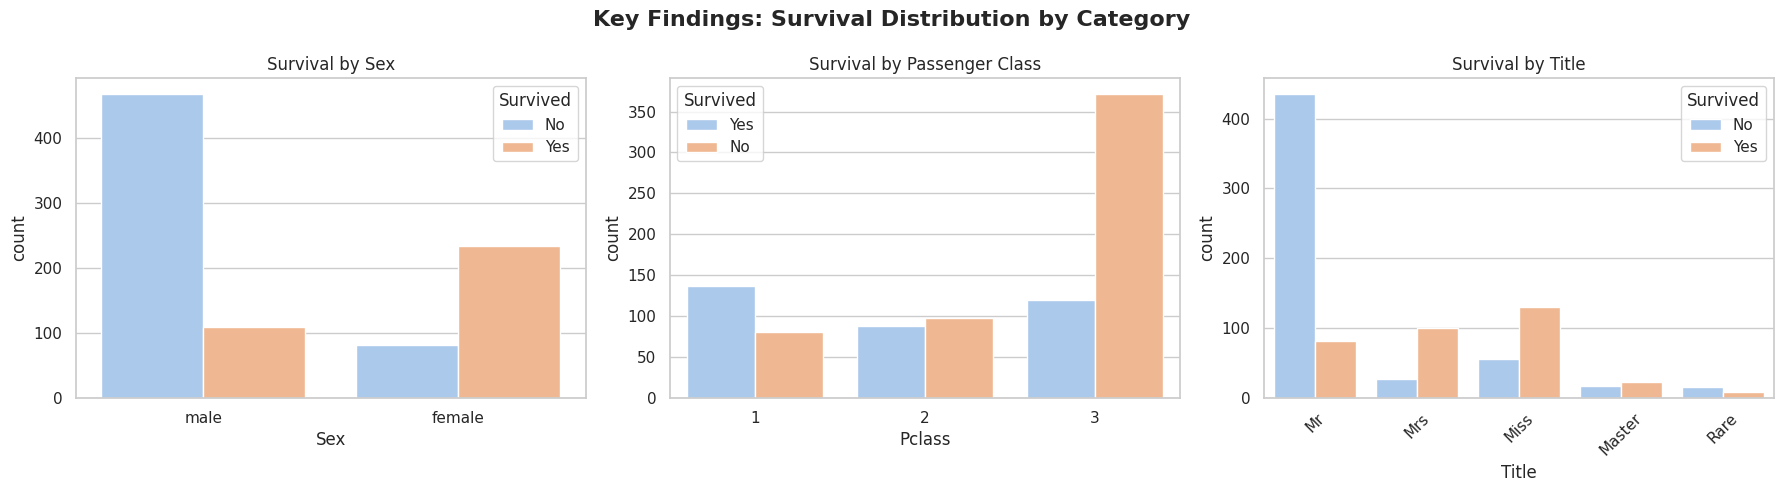

In [18]:
# Phase 7: Visualization & Reporting
sns.set_theme(style="whitegrid")

# survival distribution by category
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Key Findings: Survival Distribution by Category', fontsize=16, fontweight='bold')

# survival by Sex
sns.countplot(data=df, x='Sex', hue='Survived', palette='pastel', ax=axes[0])
axes[0].set_title('Survival by Sex', fontsize=12)

# survival by class
sns.countplot(data=df, x='Pclass', hue='Survived', palette='pastel', ax=axes[1])
axes[1].set_title('Survival by Passenger Class', fontsize=12)

# survival by the new 'Title' feature
sns.countplot(data=df, x='Title', hue='Survived', palette='pastel', ax=axes[2])
axes[2].set_title('Survival by Title', fontsize=12)
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

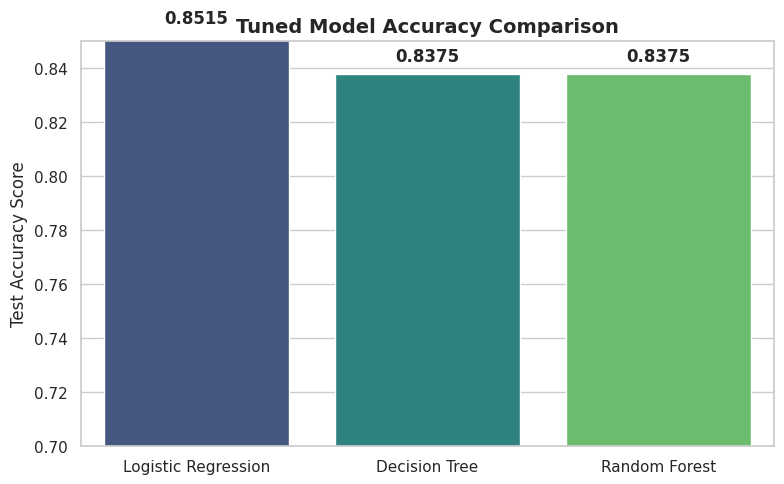

In [19]:
# model comparison summary
plt.figure(figsize=(8, 5))
model_names = list(results.keys())
model_scores = list(results.values())

ax = sns.barplot(x=model_names, y=model_scores, hue=model_names, palette='viridis', legend=False)
plt.title('Tuned Model Accuracy Comparison', fontsize=14, fontweight='bold')
plt.ylabel('Test Accuracy Score')
plt.ylim(0.70, 0.85)

# Add the exact scores on top of the bars for the presentation
for i, v in enumerate(model_scores):
    ax.text(i, v + 0.005, f"{v:.4f}", ha='center', fontweight='bold')

plt.tight_layout()
plt.show()
# save the model comparison plot
fig = ax.get_figure()
fig.savefig('model_accuracy_comparison.png', dpi=300, bbox_inches='tight')

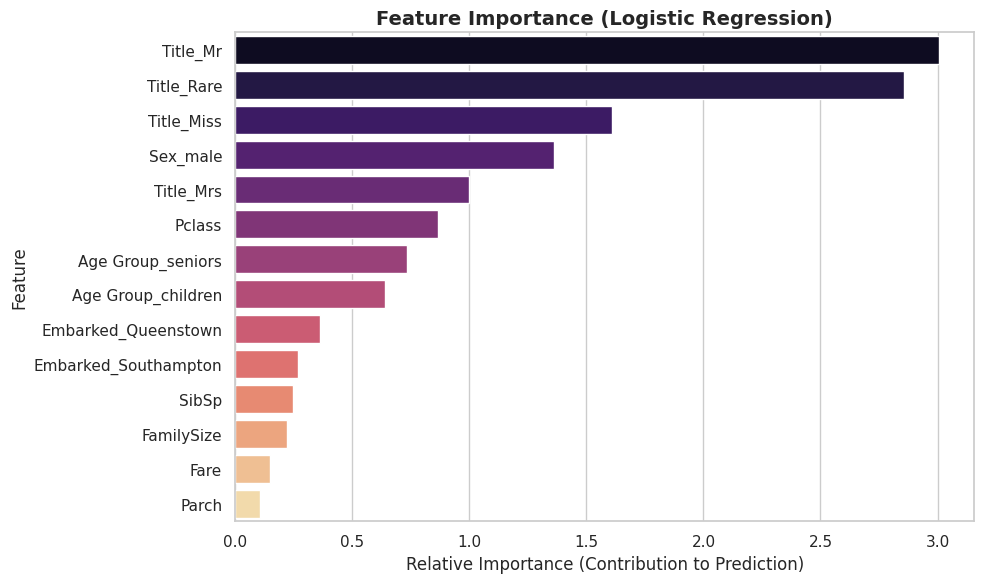

In [20]:
# important features for tree model

plt.figure(figsize=(10, 6))
# extracting feature importances from the model
best_lr_model = best_models["Logistic Regression"].named_steps['classifier']
importances = np.abs(best_lr_model.coef_[0])

# Get feature names after preprocessing
preprocessor = best_models["Logistic Regression"].named_steps['preprocessor']

# Get feature names for numerical columns
numeric_features = numeric_cols

# Get feature names for one-hot encoded categorical columns
# The OneHotEncoder returns an array, we need to map it back to feature names
cat_transformer = preprocessor.named_transformers_['cat']
categorical_feature_names = cat_transformer.get_feature_names_out(categorical_cols)

# Combine all feature names
all_feature_names = list(numeric_features) + list(categorical_feature_names)

# create a dataFrame to sort features from most to least important
feature_df = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

ax = sns.barplot(x='Importance', y='Feature', data=feature_df, hue='Feature', palette='magma', legend=False)
plt.title('Feature Importance (Logistic Regression)', fontsize=14, fontweight='bold')
plt.xlabel('Relative Importance (Contribution to Prediction)')
plt.ylabel('Feature')

plt.tight_layout()
plt.show()

# saving the feature importance plot
fig = ax.get_figure()
fig.savefig('feature_importance.png', dpi=300, bbox_inches='tight')